# ML Model --- Airplane Crash Data --- Thomas Hughes 

---

## * Initial setup *

In [98]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# encode
from sklearn.preprocessing import OneHotEncoder

# scaling
from sklearn.preprocessing import StandardScaler

# models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)

In [99]:
!pip install pycountry
import pycountry

In [100]:
# import csv
df = pd.read_csv("../Data/Airplane_Crashes_and_Fatalities_Since_1908_data.csv")

## 1. Data Quality: Pre-processing

In [101]:
# first evaluation
df.head(5)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,"First U.S. dirigible Akron exploded just offshore at an altitude of 1,000 ft. during a test flight."
1,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,"The first fatal airplane accident in Canada occurred when American barnstormer, John M. Bryant, California aviator was killed."
2,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encountered a severe downdraft crashing 20 miles north of Helgoland Island into the sea. The ship broke in two and the control car immediately sank drowning its occupants.
3,03/05/1915,01:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,21.0,0.0,Crashed into trees while attempting to land after being shot down by British and French aircraft.
4,09/03/1915,15:20,"Off Cuxhaven, Germany",Military - German Navy,NaN,NaN,Zeppelin L-10 (airship),NaN,NaN,19.0,19.0,0.0,"Exploded and burned near Neuwerk Island, when hydrogen gas, being vented, was ignited by lightning."


In [102]:
df.shape

(4741, 13)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4741 entries, 0 to 4740
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4741 non-null   object 
 1   Time          2741 non-null   object 
 2   Location      4724 non-null   object 
 3   Operator      4726 non-null   object 
 4   Flight #      967 non-null    object 
 5   Route         3196 non-null   object 
 6   Type          4717 non-null   object 
 7   Registration  4441 non-null   object 
 8   cn/In         3643 non-null   object 
 9   Aboard        4722 non-null   float64
 10  Fatalities    4730 non-null   float64
 11  Ground        4721 non-null   float64
 12  Summary       4388 non-null   object 
dtypes: float64(3), object(10)
memory usage: 481.6+ KB


In [104]:
df.isna().sum().to_frame(name="Number of nulls")

,Number of nulls
Date,0
Time,2000
Location,17
Operator,15
Flight #,3774
Route,1545
Type,24
Registration,300
cn/In,1098
Aboard,19


#### 'Date' assessment

In [105]:
# date assessment
# from .head() we can see that format is MM/DD/YYYY

print("Datatype BEFORE transformation:", df["Date"].dtype)
print("Number of null dates BEFORE transformation:", df["Date"].isna().sum())

# transform object -> datetime64
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print("----------------------------------------------")
print("Datatype AFTER transformation:", df["Date"].dtype)
print("Number of null dates AFTER object -> datetime64:", df["Date"].isna().sum())

Datatype BEFORE transformation: object
Number of null dates BEFORE transformation: 0
----------------------------------------------
Datatype AFTER transformation: datetime64[ns]
Number of null dates AFTER object -> datetime64: 0


In [106]:
print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())
print("--------------------------------")
if df["Date"].max() < pd.Timestamp.today():
    print("All dates are earlier than today")

Earliest date: 1912-07-12 00:00:00
Latest date: 2009-06-07 00:00:00
--------------------------------
All dates are earlier than today


In [107]:
# are dates in descending order?
df["Date"].is_monotonic_increasing

False

#### 'Time' assessment

In [108]:
# time assesssment
null_percent = ((df["Time"].isna().sum()/df.shape[0])*100).round(1)
print("Percentage of nulls:", null_percent, "%")

Percentage of nulls: 42.2 %


In [109]:
# first check, find values which do not have a string length of 5 (therefore must be invalid)
df["Time"].dropna().str.len().value_counts().to_frame(name="Count")

,Count
Time,
5,2726
4,7
7,5
6,3


In [110]:
# finding everything that isnt 
invalid_length_times = df["Time"].dropna()[df["Time"].dropna().str.len() != 5]

display(invalid_length_times)

168     c: 1:00
188     c:17:00
202     c: 2:00
636        1:30
1307     c16:50
2323    c:09:00
2924     114:20
3035     c14:30
3170       0943
3216       1:00
3859       2:40
4340    c: 9:40
4350       2:00
4351       8:02
4638       9:30
Name: Time, dtype: object

In [111]:
# more thorough check to find times which are string length 5 but an incorrect format
valid_time_mask = df["Time"].dropna().str.match(r"^\d{2}:\d{2}$")

print("Valid time format:", valid_time_mask.sum())
print("Invalid time format:", (~valid_time_mask).sum())

invalid_time = df["Time"].dropna()[
    ~df["Time"].dropna().str.match(r"^\d{2}:\d{2}$")
]

print("Invalid time value:", invalid_time)

Valid time format: 2725
Invalid time format: 16
Invalid time value: 168     c: 1:00
188     c:17:00
202     c: 2:00
636        1:30
1307     c16:50
2323    c:09:00
2924     114:20
3035     c14:30
3170       0943
3216       1:00
3859       2:40
4332      22'08
4340    c: 9:40
4350       2:00
4351       8:02
4638       9:30
Name: Time, dtype: object


In [112]:
# replacing all invalid values manually using a dictionary:

time_corrections = {
    "c: 1:00": "01:00",
    "c:17:00": "17:00",
    "c: 2:00": "02:00",
    "1:30": "01:30",
    "c16:50": "16:50",
    "c:09:00": "09:00",
    "114:20": np.nan,   # unclear invalid value - either number could have been mistakenly added
    "c14:30": "14:30",
    "0943": "09:43",
    "1:00": "01:00",
    "2:40": "02:40",
    "c: 9:40": "09:40",
    "2:00": "02:00",
    "8:02": "08:02",
    "9:30": "09:30",
    "22'08": "22:08"
}

In [113]:
# apply corrections
df["Time"] = df["Time"].replace(time_corrections)

In [114]:
# convert datatype from 'object' to 'datetime'
print("Data type BEFORE transformation:", df["Time"].dtype)
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%H:%M",
    errors="coerce"
)
print("Data type AFTER transformation:", df["Time"].dtype)

Data type BEFORE transformation: object
Data type AFTER transformation: datetime64[ns]


In [115]:
# create new categorical column

# create placeholder
df["Time_Period"] = "Unknown"

# create new column Time_Period which buckets:
# 00:00 -> 05:59 = Night, 06:00 -> 11:59 = Morning, 12:00 -> 17:59 = Afternoon, 18:00 -> 23:59 = Evening, Missing values = Unknown
df.loc[df["Time"].dt.hour.between(0, 5), "Time_Period"] = "Night"
df.loc[df["Time"].dt.hour.between(6, 11), "Time_Period"] = "Morning"
df.loc[df["Time"].dt.hour.between(12, 17), "Time_Period"] = "Afternoon"
df.loc[df["Time"].dt.hour.between(18, 23), "Time_Period"] = "Evening"

In [116]:
# check to make sure that categories have been assigned, and there are no nulls
display(df["Time_Period"].value_counts(dropna=False))

Time_Period
Unknown      2001
Afternoon     886
Morning       787
Evening       722
Night         345
Name: count, dtype: int64

#### 'Location' assessment 

In [117]:
null_percent = ((df["Location"].isna().sum()/df.shape[0])*100).round(1)
print("Percentage of nulls:", null_percent, "%")

Percentage of nulls: 0.4 %


In [118]:
df.head(4)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Time_Period
0,1912-07-12,1900-01-01 06:30:00,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,"First U.S. dirigible Akron exploded just offshore at an altitude of 1,000 ft. during a test flight.",Morning
1,1913-08-06,NaT,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,"The first fatal airplane accident in Canada occurred when American barnstormer, John M. Bryant, California aviator was killed.",Unknown
2,1913-09-09,1900-01-01 18:30:00,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encountered a severe downdraft crashing 20 miles north of Helgoland Island into the sea. The ship broke in two and the control car immediately sank drowning its occupants.,Evening
3,1915-03-05,1900-01-01 01:00:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,21.0,0.0,Crashed into trees while attempting to land after being shot down by British and French aircraft.,Night


In [119]:
# isolating everything after the final comma
df["Country"] = df["Location"].str.split(",").str[-1].str.strip()

In [120]:
display(df[["Location", "Country"]].sample(10))

,Location,Country
3792,"Near Irrupts, Siberia, Russia",Russia
3427,"Marseille, France",France
1766,"Jersey, UK",UK
3150,"Inverness, England",England
3116,"Imperatriz, Brazil",Brazil
1325,"Barajas, Madrid, Spain",Spain
2613,"Sunnyside, Utah",Utah
3556,"Off Newfoundland, Canada",Canada
891,"Near Huanuco, Peru",Peru
1628,"Near Brasilia, Brazil",Brazil


In [121]:
df.groupby("Country").size()

Country
110 miles West of Ireland               1
325 miles east of Wake Island           1
AK                                      1
Afghanistan                            30
Afghanstan                              2
                                       ..
Zimbabwe                                2
off Angola                              1
off Australia                           1
off Bermuda                             1
off the Philippine island of Elalat     1
Length: 474, dtype: int64

In [122]:
# set of pycountry countries
countries = {country.name for country in pycountry.countries}
#countries

In [123]:
# set of country names from pycountry
#countries = {country.name for country in pycountry.countries}
#countries

# create a lookup table (dictionary) of pycountry names
lookup = {
    country.name: country.name
    for country in pycountry.countries
}

# amend the dictionary with alias'
lookup.update({

    # adding in common/historic names which do not follow ISO
    
    "Viet Nam": "Viet Nam",
    "Vietnam": "Viet Nam",
    "Russia": "Russian Federation",
    "USSR": "Russian Federation",
    "UAE": "United Arab Emirates",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Türkiye",
    "Iran": "Iran, Islamic Republic of",
    "Taiwan": "Taiwan, Province of China",
    "Laos": "Lao People's Democratic Republic",
    "Venezuela": "Venezuela, Bolivarian Republic of",
    "Bolivia": "Bolivia, Plurinational State of",
    "South Korea": "Korea, Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
    "Yugoslavia": "Yugoslavia",
    "Soviet Union": "Russian Federation",
    "Zaire": "Congo",
    "Zaïre": "Congo",
    "Burma": "Myanmar",
    "Macedonia": "North Macedonia",
    "Rhodesia": "Zimbabwe",
    "Tanganyika": "Tanzania, United Republic of",
    "French Equatorial Africa": "French Equatorial Africa",
    "French West Africa": "French West Africa",
    "Bosnia Herzegovina": "Bosnia and Herzegovina",
    "Bosnia": "Bosnia and Herzegovina",
    "Timor": "Timor-Leste",
    "East Timor": "Timor-Leste",
    "Tanzania": "Tanzania, United Republic of",
    "Trinidad": "Trinidad and Tobago",
    "Djibouti": "Djibouti",
    "Mauritania": "Mauritania",
    "Khmer Republic": "Cambodia",
    "Upper Volta": "Burkina Faso",
    "Surinam": "Suriname",
    "Kirghizia": "Kyrgyzstan",
    "Czech Republic": "Czechia",
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Saskatchewan": "Canada",
    "Manitoba": "Canada",
    "British Columbia": "Canada",
    "Tasmania": "Tasmania",
    "Caribbean": "Caribbean",
    "Cape Verde Islands": "Cabo Verde",
    "Sainte Lucia Island": "Saint Lucia",
    "Grenadines Islands": "Grenadines",
    "Antigua": "Antigua and Barbuda",
    "Brunei": "Brunei Darussalam",
    "Chechnya": "Russian Federation",
    "Ivory Coast": "Côte d'Ivoire",
    "Malagasy Republic": "Madagascar",
    "UAR": "Egypt",
    "Malaya": "Malaysia",
    "French Equitorial Africa": "French Equatorial Africa",
    "Reunion": "Réunion",
    "Moldova": "Moldova, Republic of",

    # UK states
    
    "England": "United Kingdom",
    "Scotland": "United Kingdom",
    "Wales": "United Kingdom",
    "Northern Ireland": "United Kingdom",

    # Territories/ Islands:

    "Newfoundland": "Newfoundland",
    "Virgin Islands": "Virgin Islands, U.S.",
    "British Virgin Islands": "Virgin Islands, British",
    "U.S. Virgin Islands": "Virgin Islands, U.S.",
    "US Virgin Islands": "Virgin Islands, U.S.",
    "Canary Islands": "Canary Islands",
    "Azores": "Azores",
    "West Indies": "West Indies",
    "Comoro Islands": "Comoros",
    "Turks & Caicos Islands": "Turks and Caicos Islands",
    "Leeward Islands": "Leeward Islands",
    "Crete": "Crete",
    "Okinawa": "Okinawa",
    "Eugene Island": "Eugene Island",
    "Islay Island": "Islay Island",
    "Mariana Islands": "Mariana Islands",
    "Isle of man": "Isle of Man",
    "Sao Tomé & Principe": "Sao Tome and Principe",
    "Grenadines": "Grenadines",
    "Borneo": "Borneo",
    "Great Inagua": "Great Inagua",
    "Bimini": "Bimini",
    "Off  Bimini": "Bimini",

    # USA states

    "Alabama": "Alabama",
    "Alaska": "Alaska",
    "Arizona": "Arizona",
    "Arkansas": "Arkansas",
    "California": "California",
    "Colorado": "Colorado",
    "Connecticut": "Connecticut",
    "Delaware": "Delaware",
    "Florida": "Florida",
    "Georgia": "Georgia",
    "Hawaii": "Hawaii",
    "Idaho": "Idaho",
    "Illinois": "Illinois",
    "Indiana": "Indiana",
    "Iowa": "Iowa",
    "Kansas": "Kansas",
    "Kentucky": "Kentucky",
    "Louisiana": "Louisiana",
    "Maine": "Maine",
    "Maryland": "Maryland",
    "Massachusetts": "Massachusetts",
    "Michigan": "Michigan",
    "Minnesota": "Minnesota",
    "Mississippi": "Mississippi",
    "Missouri": "Missouri",
    "Montana": "Montana",
    "Nebraska": "Nebraska",
    "Nevada": "Nevada",
    "New Hampshire": "New Hampshire",
    "New Jersey": "New Jersey",
    "New Mexico": "New Mexico",
    "New York": "New York",
    "North Carolina": "North Carolina",
    "North Dakota": "North Dakota",
    "Ohio": "Ohio",
    "Oklahoma": "Oklahoma",
    "Oregon": "Oregon",
    "Pennsylvania": "Pennsylvania",
    "Rhode Island": "Rhode Island",
    "South Carolina": "South Carolina",
    "South Dakota": "South Dakota",
    "Tennessee": "Tennessee",
    "Texas": "Texas",
    "Utah": "Utah",
    "Vermont": "Vermont",
    "Virginia": "Virginia",
    "Washington": "Washington",
    "West Virginia": "West Virginia",
    "Wisconsin": "Wisconsin",
    "Wyoming": "Wyoming",

    # Water:

    # Oceans
    "Atlantic Ocean": "Atlantic Ocean",
    "AtlanticOcean": "Atlantic Ocean",
    "AtlantiOcean": "Atlantic Ocean",
    "North AtlanticOcean": "Atlantic Ocean",
    "South AtlanticOcean": "Atlantic Ocean",

    "Pacific Ocean": "Pacific Ocean",
    "PacificOcean": "Pacific Ocean",
    "PacifiOcean": "Pacific Ocean",
    "North PacificOcean": "Pacific Ocean",

    # Seas
    "North Sea": "North Sea",
    "Baltic Sea": "Baltic Sea",
    "Black Sea": "Black Sea",
    "Mediterranean Sea": "Mediterranean Sea",
    "Philippine Sea": "Philippine Sea",
    "Andaman Sea": "Andaman Sea",

    # Gulfs
    "Persian Gulf": "Persian Gulf",
    "Gulf of Sirte": "Gulf of Sirte",
    "Gulf of Tonkin": "Gulf of Tonkin",

    # Channels / Straits
    "English Channel": "English Channel",
    "Formosa Strait": "Taiwan Strait",

    # "Over ..." variants
    "Over the AtlanticOcean": "Atlantic Ocean",
    "Over the AtlantiOcean": "Atlantic Ocean",
    "Over the North Atlantic": "Atlantic Ocean",
    "North Atlantic": "Atlantic Ocean",   
    "Over the PacificOcean": "Pacific Ocean",
    "Over the PacifiOcean": "Pacific Ocean",
    "Over the North PacificOcean": "Pacific Ocean",
    "Over the Mediterranean Sea": "Mediterranean Sea",
    "Over the North Sea": "North Sea",
    "Over the English Channel": "English Channel",
    "Over the Andaman Sea": "Andaman Sea",

    # spelling mistakes and ambiguous fixes

    "Massachusett": "Massachusetts",
    "Massachutes": "Massachusetts",
    "Tennesee": "Tennessee",
    "Wisconson": "Wisconsin",
    "Alaksa": "Alaska",
    "Alakska": "Alaska",
    "Washingon": "Washington",
    "Afghanstan": "Afghanistan",
    "Minnisota": "Minnesota",
    "Boliva": "Bolivia",
    "Mauretania": "Mauritania",
    "Coloado": "Colorado",
    "Napal": "Nepal",
    "Philipines": "Philippines",
    "Phillipines": "Philippines",
    "Hunary": "Hungary",
    "Calilfornia": "California",
    "Cailifornia": "California",
    "Djbouti": "Djibouti",
    "Morroco": "Morocco",
    "Morrocco": "Morocco",
    "Yugosalvia": "Yugoslavia",
    "Manmar": "Myanmar",
    "Hati": "Haiti",
    "Domincan Republic": "Dominican Republic",
    "DemocratiRepubliCogo": "Congo, The Democratic Republic of the",
    "Airzona": "Arizona",
    "Oklohoma": "Oklahoma",
    "Thiland": "Thailand",
    "Sierre Leone": "Sierra Leone",
    "Bulgeria": "Bulgaria",
    "Bugaria": "Bulgaria",
    "Ilinois": "Illinois",
    "Arazona": "Arizona",
    "Deleware": "Delaware",
    "Romainia": "Romania",
    "Jamacia": "Jamaica",
    "Aregntina": "Argentina",
    "Baangladesh": "Bangladesh",
    "Mocambique": "Mozambique",
    "Louisana": "Louisiana",
    "South Dekota": "South Dakota",
    "Midway Island Naval Air Station": "United States Minor Outlying Islands",

    #abbreviations of states
    "AK": "Alaska",
    "CA": "California",
    "GA": "Georgia",
    "HI": "Hawaii",
    "NY": "New York",
    "WY": "Wyoming",
    "UK": "United Kingdom",
    "D.C.": "Washington D.C.",

    #cities/areas within countries
    "Algiers": "Algeria",
    "Vienna": "Austria",
    "Amsterdam": "Netherlands",
    "London": "United Kingdom",
    "Buenos Aires": "Argentina",
    "Sao Tomé": "Sao Tome and Principe",
    "Milford Sound": "New Zealand",
    "Near Moscow": "Russian Federation",
    "Near Karkov": "Ukraine"
})

In [124]:
# sorting order
search_terms = sorted(
    lookup.keys(),
    key=len,
    reverse=True
)

In [125]:
# extraction function
def extract_country(location):
    # this function ...
    if pd.isna(location):
        return location

    location_lower = location.lower()

    for term in search_terms:
        if term.lower() in location_lower:
            return lookup[term]

    return location

df["Country"] = df["Country"].apply(extract_country)

In [126]:
# find left over values
display(
    df.loc[
        ~df["Country"].isin(lookup),
        "Country"
    ].value_counts()
)

Country
Washington D.C.           2
Over the Mediterranean    1
Ile of Man                1
BaltiSea                  1
Off Irish coast           1
Taiwan Strait             1
Near Nag                  1
BO                        1
Name: count, dtype: int64

In [127]:
# turing the remaining 4 values to null (Over the Mediterranean, Off Irish coast, Near Nag, BO) 
df.loc[
    df["Country"].isin([
        "Over the Mediterranean",
        "Off Irish coast",
        "Near Nag",
        "BO"
    ]),
    "Country"
] = np.nan

In [128]:
# further reduce to us states, continent, body of water, islands/territories, unknowns

us_states = {
    "Alabama","Alaska","Arizona","Arkansas","California","Colorado",
    "Connecticut","Delaware","Florida","Georgia","Hawaii","Idaho",
    "Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana",
    "Maine","Maryland","Massachusetts","Michigan","Minnesota",
    "Mississippi","Missouri","Montana","Nebraska","Nevada",
    "New Hampshire","New Jersey","New Mexico","New York",
    "North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
    "Pennsylvania","Rhode Island","South Carolina","South Dakota",
    "Tennessee","Texas","Utah","Vermont","Virginia","Washington",
    "West Virginia","Wisconsin","Wyoming","Washington D.C."
}

df.loc[df["Country"].isin(us_states), "Country"] = "United States"

# create region lookup
region_lookup = {

    # North America
    "United States": "North America",
    "Canada": "North America",
    "Mexico": "North America",
    "Bahamas": "North America",
    "Cuba": "North America",
    "Jamaica": "North America",
    "Dominican Republic": "North America",
    "Haiti": "North America",
    "Trinidad and Tobago": "North America",
    "Antigua and Barbuda": "North America",
    "Saint Lucia": "North America",
    "Côte d'Ivoire": "Africa",
    "Puerto Rico": "North America",
    "Honduras": "North America",
    "Guatemala": "North America",
    "Guadeloupe": "North America",
    "Nicaragua": "North America",
    "Panama": "North America",
    "Virgin Islands, U.S.": "North America",
    "Costa Rica": "North America",
    "Greenland": "North America",
    "Guam": "North America",
    "El Salvador": "North America",
    "Bermuda": "North America",
    "Turks and Caicos Islands": "North America",
    "Barbados": "North America",
    "American Samoa": "North America",
    "Martinique": "North America",
    "Dominica": "North America",
    "Belize": "North America",

    # South America
    "Argentina": "South America",
    "Brazil": "South America",
    "Chile": "South America",
    "Colombia": "South America",
    "Ecuador": "South America",
    "Guyana": "South America",
    "Paraguay": "South America",
    "Peru": "South America",
    "Suriname": "South America",
    "Uruguay": "South America",
    "Venezuela, Bolivarian Republic of": "South America",
    "Bolivia, Plurinational State of": "South America",

    # Europe
    "United Kingdom": "Europe",
    "Ireland": "Europe",
    "France": "Europe",
    "Germany": "Europe",
    "Austria": "Europe",
    "Belgium": "Europe",
    "Netherlands": "Europe",
    "Switzerland": "Europe",
    "Italy": "Europe",
    "Spain": "Europe",
    "Portugal": "Europe",
    "Norway": "Europe",
    "Sweden": "Europe",
    "Finland": "Europe",
    "Denmark": "Europe",
    "Poland": "Europe",
    "Czechia": "Europe",
    "Romania": "Europe",
    "Hungary": "Europe",
    "Bulgaria": "Europe",
    "Greece": "Europe",
    "Croatia": "Europe",
    "Serbia": "Europe",
    "Bosnia and Herzegovina": "Europe",
    "North Macedonia": "Europe",
    "Ukraine": "Europe",
    "Russian Federation": "Europe",
    "Yugoslavia": "Europe",
    "Jersey": "Europe",
    "Lithuania": "Europe",
    "Moldova, Republic of": "Europe",
    "Slovakia": "Europe",
    "Malta": "Europe",
    "Estonia": "Europe",
    "Iceland": "Europe",
    "Gibraltar": "Europe",
    "Cyprus": "Europe",
    "Luxembourg": "Europe",
    "Latvia": "Europe",
    "Albania": "Europe",
    "Slovenia": "Europe",
    "Isle of Man": "Europe",

    # Asia
    "China": "Asia",
    "Japan": "Asia",
    "India": "Asia",
    "Pakistan": "Asia",
    "Afghanistan": "Asia",
    "Thailand": "Asia",
    "Myanmar": "Asia",
    "Malaysia": "Asia",
    "Indonesia": "Asia",
    "Philippines": "Asia",
    "Singapore": "Asia",
    "Viet Nam": "Asia",
    "Lao People's Democratic Republic": "Asia",
    "Cambodia": "Asia",
    "Korea, Republic of": "Asia",
    "Korea, Democratic People's Republic of": "Asia",
    "Taiwan, Province of China": "Asia",
    "Türkiye": "Asia",
    "Iran, Islamic Republic of": "Asia",
    "Iraq": "Asia",
    "Saudi Arabia": "Asia",
    "United Arab Emirates": "Asia",
    "Jordan": "Asia",
    "Israel": "Asia",
    "Syrian Arab Republic": "Asia",
    "Yemen": "Asia",
    "Kazakhstan": "Asia",
    "Kyrgyzstan": "Asia",
    "Nepal": "Asia",
    "Sri Lanka": "Asia",
    "Timor-Leste": "Asia",
    "Brunei Darussalam": "Asia",
    "Hong Kong": "Asia",
    "Lebanon": "Asia",
    "Mongolia": "Asia",
    "Uzbekistan": "Asia",
    "Azerbaijan": "Asia",
    "Bangladesh": "Asia",
    "Armenia": "Asia",
    "Qatar": "Asia",
    "Oman": "Asia",
    "Kuwait": "Asia",
    "Bhutan": "Asia",
    "Turkmenistan": "Asia",
    "Tajikistan": "Asia",
    "Bahrain": "Asia",

    # Africa
    "Algeria": "Africa",
    "Angola": "Africa",
    "Botswana": "Africa",
    "Burkina Faso": "Africa",
    "Burundi": "Africa",
    "Cameroon": "Africa",
    "Cabo Verde": "Africa",
    "Central African Republic": "Africa",
    "Chad": "Africa",
    "Comoros": "Africa",
    "Congo": "Africa",
    "Congo, The Democratic Republic of the": "Africa",
    "Djibouti": "Africa",
    "Egypt": "Africa",
    "Equatorial Guinea": "Africa",
    "Ethiopia": "Africa",
    "Gabon": "Africa",
    "Ghana": "Africa",
    "Kenya": "Africa",
    "Libya": "Africa",
    "Madagascar": "Africa",
    "Malawi": "Africa",
    "Mali": "Africa",
    "Mauritania": "Africa",
    "Morocco": "Africa",
    "Mozambique": "Africa",
    "Namibia": "Africa",
    "Nigeria": "Africa",
    "Rwanda": "Africa",
    "Senegal": "Africa",
    "Sierra Leone": "Africa",
    "Somalia": "Africa",
    "South Africa": "Africa",
    "Sudan": "Africa",
    "Tanzania, United Republic of": "Africa",
    "Tunisia": "Africa",
    "Uganda": "Africa",
    "Zambia": "Africa",
    "Zimbabwe": "Africa",
    "French Equatorial Africa": "Africa",
    "French West Africa": "Africa",
    "Réunion": "Africa",
    "Guinea": "Africa",
    "Gambia": "Africa",
    "Niger": "Africa",
    "Liberia": "Africa",
    "Sao Tome and Principe": "Africa",
    "Eritrea": "Africa",
    "Lesotho": "Africa",
    "Benin": "Africa",

    # Oceania
    "Australia": "Oceania",
    "New Zealand": "Oceania",
    "Papua New Guinea": "Oceania",
    "Fiji": "Oceania",
    "Samoa": "Oceania",
    "Tonga": "Oceania",
    "Vanuatu": "Oceania",
    "United States Minor Outlying Islands": "Oceania",
    "French Polynesia": "Oceania",
    "Solomon Islands": "Oceania",
    "Cook Islands": "Oceania",
    "Marshall Islands": "Oceania",
    "Tasmania": "Oceania",

    # Antarctica
    "Antarctica": "Antarctica",

    # Water
    "Atlantic Ocean": "Water",
    "Pacific Ocean": "Water",
    "North Sea": "Water",
    "Baltic Sea": "Water",
    "Black Sea": "Water",
    "Mediterranean Sea": "Water",
    "Philippine Sea": "Water",
    "Andaman Sea": "Water",
    "Persian Gulf": "Water",
    "Gulf of Sirte": "Water",
    "Gulf of Tonkin": "Water",
    "English Channel": "Water",
    "Taiwan Strait": "Water",

    # Islands / Territories
    "Newfoundland": "Island",
    "Canary Islands": "Island",
    "Azores": "Island",
    "West Indies": "Island",
    "Leeward Islands": "Island",
    "Crete": "Island",
    "Okinawa": "Island",
    "Eugene Island": "Island",
    "Islay Island": "Island",
    "Mariana Islands": "Island",
    "Borneo": "Island",
    "Grenadines": "Island",
    "Great Inagua": "Island",
    "Bimini": "Island",
    "Caribbean": "Island"
}

df["Region"] = df["Country"].map(region_lookup)

# anything unmapped becomes Unknown
df["Region"] = df["Region"].fillna("Unknown")

print(df["Region"].value_counts())

Region
North America    1680
Europe            960
Asia              845
South America     558
Africa            433
Oceania           134
Water              70
Island             34
Unknown            26
Antarctica          1
Name: count, dtype: int64


In [129]:
# final check
display(
    df.loc[df["Region"] == "Unknown", "Country"]
      .value_counts()
      .head(100)
)

Country
Bolivia                    2
Ile of Man                 1
BaltiSea                   1
Virgin Islands, British    1
Name: count, dtype: int64

#### 'Operator' column assessment

In [130]:
# inital inspections
#df.groupby("Operator").size()
df["Operator"].value_counts()

Operator
Aeroflot                           160
Military - U.S. Air Force          160
Air France                          63
Deutsche Lufthansa                  61
Military - U.S. Army Air Forces     42
                                  ... 
Southeast Sky - Air Taxi             1
Pan ArctiOil                         1
Hlavka Aviation - Air Taxi           1
Alaska International Air             1
Strait Air                           1
Name: count, Length: 2289, dtype: int64

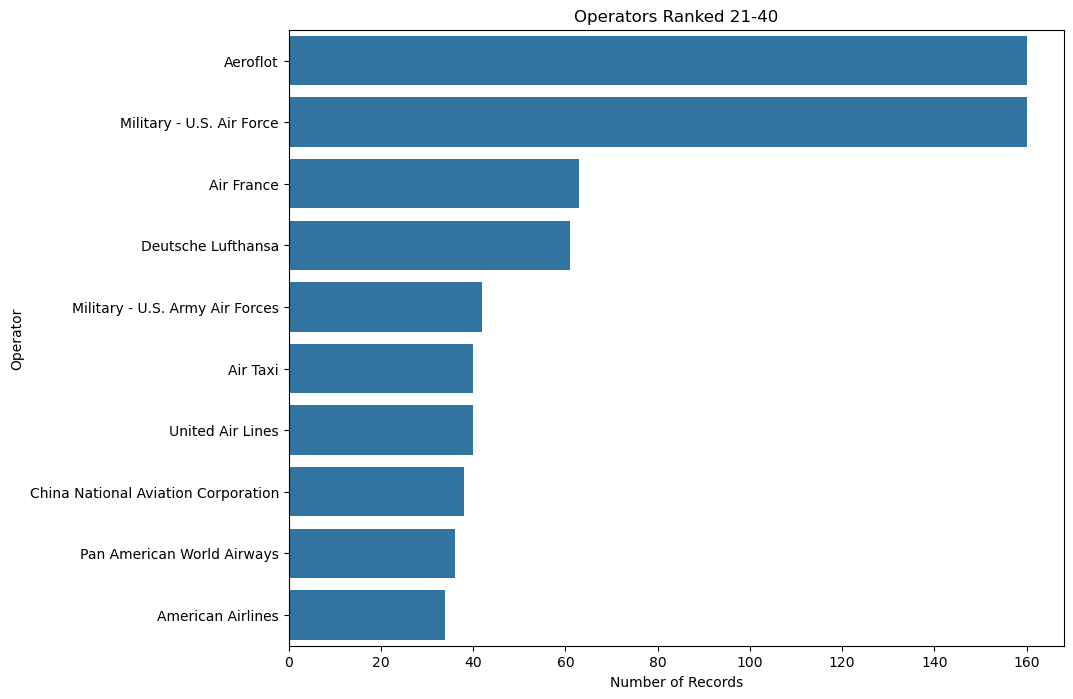

In [131]:
# inital count inspections
ops = df["Operator"].value_counts().iloc[0:10]

plt.figure(figsize=(10,8))
sns.barplot(
    x=ops.values,
    y=ops.index
)

plt.title("Operators Ranked 21-40")
plt.xlabel("Number of Records")
plt.ylabel("Operator")
plt.show()

In [132]:
# after inspection, split into buckets
# Start with default
df["Operator_Type"] = "Commercial"

# original Operator column had 15 nulls -> these become unknown 
df.loc[
    df["Operator"].isna(),
    "Operator_Type"
] = "Unknown"

# Military
df.loc[
    df["Operator"].str.contains(
        "Military|Army|Navy",
        case=False,
        na=False
    ),
    "Operator_Type"
] = "Military"

# Private
df.loc[
    df["Operator"].str.contains(
        "Private",
        case=False,
        na=False
    ),
    "Operator_Type"
] = "Private"

# Air Taxi
df.loc[
    df["Operator"].str.contains(
        "Taxi",
        case=False,
        na=False
    ),
    "Operator_Type"
] = "Air Taxi"

df.loc[
    df["Operator"].str.contains(
        "Cargo|Freight|Mail|Postal",
        case=False,
        na=False
    ),
    "Operator_Type"
] = "Cargo/Mail"

# Helicopter (overrides Air Taxi if both)
df.loc[
    df["Operator"].str.contains(
        "Helicopter",
        case=False,
        na=False
    ),
    "Operator_Type"
] = "Helicopter"

In [133]:
# unknown category becomes 15, consistent with 15 nulls found in 'Operator' column
df["Operator_Type"].value_counts()

Operator_Type
Commercial    3423
Military       705
Air Taxi       365
Cargo/Mail     110
Private         71
Helicopter      52
Unknown         15
Name: count, dtype: int64

In [134]:
df.groupby("Operator_Type")["Operator"].nunique()

Operator_Type
Air Taxi       297
Cargo/Mail      46
Commercial    1660
Helicopter      47
Military       198
Private         41
Unknown          0
Name: Operator, dtype: int64

In [135]:
# check nulls have become zero
df['Operator_Type'].isna().sum()

np.int64(0)

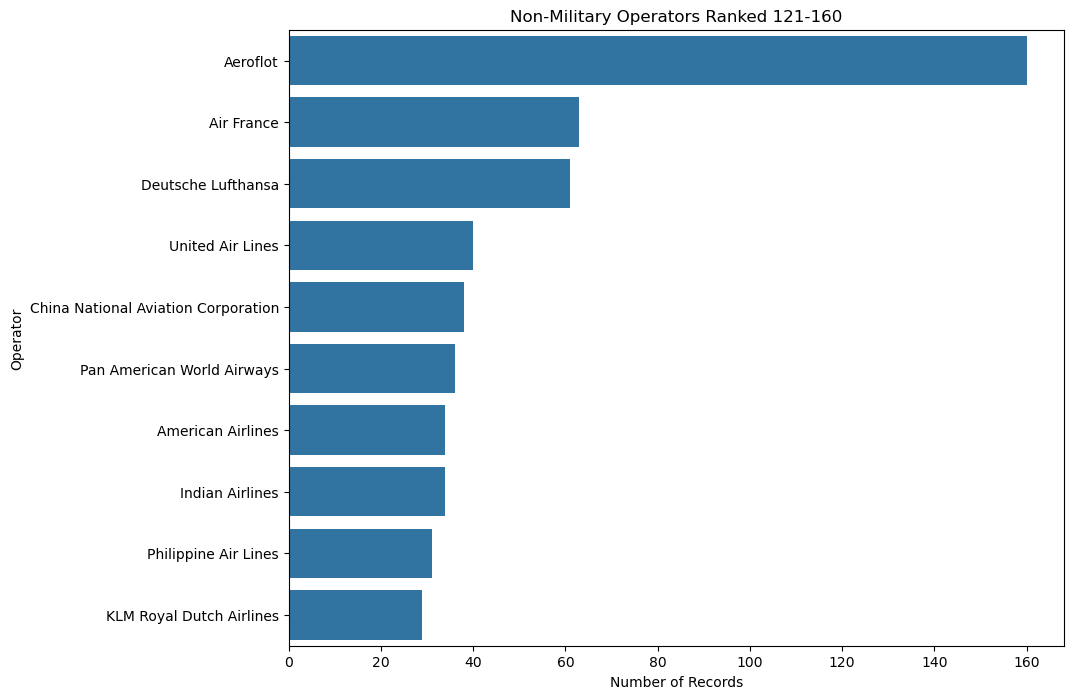

In [136]:
# graph to show counts of each category
ops = (
    df.loc[df["Operator_Type"] == "Commercial", "Operator"]
      .value_counts()
      .iloc[0:10]
)

plt.figure(figsize=(10,8))
sns.barplot(
    x=ops.values,
    y=ops.index
)

plt.title("Non-Military Operators Ranked 121-160")
plt.xlabel("Number of Records")
plt.ylabel("Operator")

plt.show()

In [137]:
df.loc[
    df["Operator"].str.contains("taxi", case=False, na=False),
    "Operator"
].value_counts()

Operator
Air Taxi                            40
Commercial Air Taxi                 10
Taxi Aereo el Venado                 5
Air taxi                             4
Kenai Air Service - Air Taxi         3
                                    ..
Henry Nichols - Air Taxi             1
AltusFlying Service - Air Taxi       1
Deming Flying Service - Air Taxi     1
Webber Airlines -Air Taxi            1
Aerotaxi Manaus                      1
Name: count, Length: 321, dtype: int64

In [138]:
df.loc[
    df["Operator"].str.contains("private", case=False, na=False),
    "Operator"
].value_counts()

Operator
Private                                      29
Trans World Airlines / Private                2
Piedmont Airlines / Private                   2
Wings West Airlines / Private                 1
Private - WNBC                                1
Skywest Airlines / Private.                   1
Corporate Mobility Inc. - Private             1
Private Wings                                 1
United Express  / Private                     1
Proteus Air / Private                         1
Patuxent Airways / Private                    1
Jetwingsco Inc. - Private Charter             1
Air US / Private                              1
Private - Techint  group                      1
Private  - Daewoo Shipbuilding                1
Private - OverteCompany                       1
Blackhawk Int. Airways  - Private charter     1
Scandinavian Airlines (SAS) / Private         1
Private - Kabanov - skydiving                 1
Med Flight Air Ambulance - Private            1
Gol Airlines / Private         

In [139]:
df.loc[
    df["Operator"].str.contains("helicopter", case=False, na=False),
    "Operator"
].value_counts()

Operator
Petroleum Helicopter                              4
Bristow Helicopters                               3
HiTech Helicopters                                1
Air Taxi - Airis Helicopters Inc.                 1
Air Taxi - Western Helicopter Inc.                1
Air Taxi - Hawaii Helicopters Inc.                1
Air Taxi - South Coast Helicopters Inc.           1
Air Taxi - National Helicopters                   1
Air Taxi - US Helicopters Inc.                    1
Air Taxi - Ohana Helicopter Tours                 1
Air Taxi - Coastal Helicopters Inc.               1
Blue Hawaiian Helicopters                         1
Chicago Helicopter Airways                        1
Paradise Tour Helicopters                         1
BHS - Brazilian Helicopter Services               1
Jack Harter Helicopters                           1
Sundance Helicopters                              1
BHS - Brazilian Helicopter Service  Air Taxi      1
Evergreen Alaska Helicopters, Inc.                1
BHS

In [140]:
# assessing overlap
taxi_mask = df["Operator"].str.contains("taxi", case=False, na=False)

heli_mask = df["Operator"].str.contains("helicopter", case=False, na=False)

print("Taxi:", taxi_mask.sum())
print("Helicopter:", heli_mask.sum())
print("Both:", (taxi_mask & heli_mask).sum())

Taxi: 389
Helicopter: 52
Both: 24


In [141]:
df.loc[
    df["Operator_Type"] == "Commercial",
    "Operator"
].value_counts().sample(50)

Operator
Tyumen Aviatrans                                    1
Intercontinental de Aviacion                        1
Lineas Aereas Nacionales SA (Peru)                  2
Evergreen International Airlines                    1
Haïti Air Inter                                     2
Mexican Government                                  1
Fuerza Aérea Uruguaya                               1
California Air National Guard                       1
Aeroejecutivos Colombia                             1
Cabo Verde Airlines                                 1
Lineas Aereas de Espana/Spantax SA Transportes      1
Kivu Air Services                                   1
Alpha Airways                                       1
New England Aviaiton                                1
Great Lakes Business Complany                       1
Aerial Transit Company                              1
Det Danske Luftfartselskab                          1
Lineas Areas Venezolanas                            1
Compania de Aviacio

In [142]:
df.loc[
    df["Operator"].str.contains(
        "Cargo|Freight|Mail|Postal",
        case=False,
        na=False
    ),
    "Operator"
].value_counts()

Operator
US Aerial Mail Service                                33
Aeropostale                                           19
Linea Aeropostal Venezolana                           11
Mountain Air Cargo                                     2
Scibe Airlift Cargo Zaire                              2
Regina Cargo Airlines                                  2
Air Freight New Zealand                                2
Prestige Airlines (Cargo) Charter                      1
Air Cargo Express                                      1
Moldovan Aeriantur-M Air Cargo                         1
Dodita Air Cargo                                       1
Canair Cargo                                           1
Golden Star Air Cargo                                  1
Ukrainian Cargo Airlines -  Congolese Army Charter     1
Cargo Three Panama                                     1
Heavylift Cargo Airlines                               1
North Star Air Cargo                                   1
Northern Air Cargo    

#### 'Flight #' column

In [143]:
df["Flight #"].value_counts()

Flight #
-      62
1      10
4       6
21      6
101     6
       ..
932     1
863     1
621     1
215     1
447     1
Name: count, Length: 670, dtype: int64

In [144]:
# analysis of flight #s
print("Total rows:", df.shape[0])
print("Number of null flight #s:", df["Flight #"].isna().sum())
print("% of data that is null:", ((df["Flight #"].isna().sum())/(df.shape[0])*100).round(1))
print("Number of non-null flight #s:", (df.shape[0])-(df["Flight #"].isna().sum()))
print("Number of unique flight #s:", df["Flight #"].nunique())

Total rows: 4741
Number of null flight #s: 3774
% of data that is null: 79.6
Number of non-null flight #s: 967
Number of unique flight #s: 670


In [145]:
# flight #s are essentially identifiers, and most the data is null, so dropping the flight # column for the model

#### 'Route' column assessment

In [146]:
df["Route"].value_counts().head(10)

Route
Training                      73
Sightseeing                   27
Test flight                   16
Test                           5
Sao Paulo - Rio de Janeiro     4
Bogota - Barranquilla          4
Sao Paulo - Porto Alegre       4
Rome - Athens                  3
Davao - Manila                 3
Rio de Janeiro - Sao Paulo     3
Name: count, dtype: int64

In [147]:
# extracting training, sightseeing, and test flight into seperate columns, and dropping route
df["Training_Flight"] = (
    df["Route"].str.contains("Training", case=False, na=False)
).astype(int)

df["Test_Flight"] = (
    df["Route"].str.contains("Test", case=False, na=False)
).astype(int)

df["Sightseeing_Flight"] = (
    df["Route"].str.contains("Sightseeing", case=False, na=False)
).astype(int)

In [148]:
df.head(3)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Time_Period,Country,Region,Operator_Type,Training_Flight,Test_Flight,Sightseeing_Flight
0,1912-07-12,1900-01-01 06:30:00,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,"First U.S. dirigible Akron exploded just offshore at an altitude of 1,000 ft. during a test flight.",Morning,United States,North America,Military,0,1,0
1,1913-08-06,NaT,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,"The first fatal airplane accident in Canada occurred when American barnstormer, John M. Bryant, California aviator was killed.",Unknown,Canada,North America,Private,0,0,0
2,1913-09-09,1900-01-01 18:30:00,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encountered a severe downdraft crashing 20 miles north of Helgoland Island into the sea. The ship broke in two and the control car immediately sank drowning its occupants.,Evening,North Sea,Water,Military,0,0,0


#### 'Type' column assessment

In [149]:
df["Type"].value_counts().head(10)

Type
Douglas DC-3                                290
de Havilland Canada DHC-6 Twin Otter 300     70
Douglas C-47A                                67
Douglas C-47                                 58
Douglas DC-4                                 35
Antonov AN-26                                33
Yakovlev YAK-40                              33
Junkers JU-52/3m                             31
De Havilland DH-4                            27
Douglas C-47B                                26
Name: count, dtype: int64

In [150]:
print("Nulls:", df["Type"].isna().sum())
print("Unique types:", df["Type"].nunique())

Nulls: 24
Unique types: 2269


In [151]:
df["Manufacturer"] = (
    df["Type"]
    .fillna("Unknown")
    .str.lower()      # makes all text lowercase
    .str.split()
    .str[0]
)

print(df["Manufacturer"].value_counts().head(50))

Manufacturer
douglas           871
boeing            341
lockheed          302
de                269
cessna            262
antonov           222
fokker            121
piper             119
mcdonnell         113
beechcraft        112
curtiss           111
vickers            87
ilyushin           83
tupolev            83
junkers            79
convair            76
fairchild          68
britten-norman     61
embraer            57
bell               57
sikorsky           45
learjet            45
yakovlev           44
avro               40
consolidated       39
beech              36
casa               33
hawker             31
airbus             31
swearingen         30
let                29
mil                29
aerospatiale       27
short              26
bristol            24
unknown            24
ford               23
grumman            22
handley            21
britten            20
martin             19
breguet            19
shorts             17
dornier            16
latecoere          

In [152]:
df["Manufacturer"] = df["Manufacturer"].replace({
    "de": "de_havilland",
    "beech": "beechcraft",
    "britten": "britten-norman",
    "short": "shorts",
    "aero": "aero_commander",
    "british": "british_aerospace",
    "handley": "handley_page",
    "curtiss-wright": "curtiss"
})

In [153]:
top_50 = df["Manufacturer"].value_counts().head(50).index

df["Manufacturer"] = df["Manufacturer"].where(
    df["Manufacturer"].isin(top_50),
    "other"
)

In [154]:
df.groupby("Manufacturer").size()

Manufacturer
aero_commander        12
aerospatiale          27
airbus                31
antonov              222
avro                  40
bac                   15
beechcraft           148
bell                  57
boeing               341
breguet               19
bristol               24
british_aerospace     15
britten-norman        81
canadair              15
casa                  33
cessna               262
consolidated          39
convair               76
curtiss              123
de_havilland         269
dornier               16
douglas              871
embraer               57
fairchild             68
farman                11
fokker               121
ford                  23
grumman               22
handley_page          21
hawker                31
ilyushin              83
junkers               79
latecoere             16
learjet               45
let                   29
lockheed             302
martin                19
mcdonnell            113
mil                   29
other       

#### 'Registration' column assessment

In [155]:
df.groupby("Registration").size()

Registration
 /               1
01 / 02 / 03     1
011              1
012              1
01710 / 69113    1
                ..
ZS-ONT           1
ZS-OYI           1
ZS-PDV           1
ZS-POG           1
ZS-SAS           1
Length: 4420, dtype: int64

In [156]:
print("Total rows:", df.shape[0])
print("Number of null Registrations:", df["Registration"].isna().sum())
print("% of non-nulls that are unique:", round(df["Registration"].nunique() / df["Registration"].notna().sum() * 100, 1))
print("% of data that is null:", ((df["Registration"].isna().sum())/(df.shape[0])*100).round(1))
print("Number of non-null Registrations:", (df.shape[0])-(df["Registration"].isna().sum()))
print("Number of unique Registrations:", df["Registration"].nunique())


print(df["Registration"].nunique())
print(df["Registration"].isna().sum())
print(df.shape[0])

Total rows: 4741
Number of null Registrations: 300
% of non-nulls that are unique: 99.5
% of data that is null: 6.3
Number of non-null Registrations: 4441
Number of unique Registrations: 4420
4420
300
4741


#### 'cn/ln' column assessment

In [157]:
df["cn/In"].value_counts()

cn/In
178         5
229         5
213         5
125         5
19          5
           ..
2041        1
27307905    1
4413        1
2023        1
424         1
Name: count, Length: 3365, dtype: int64

In [158]:
# stats to see if the data is identifier/unique data
print("Total rows:", df.shape[0])
print("Number of null cn/In:", df["cn/In"].isna().sum())
print("% of non-nulls that are unique:", round(df["cn/In"].nunique() / df["cn/In"].notna().sum() * 100, 1))
print("% of data that is null:", ((df["cn/In"].isna().sum())/(df.shape[0])*100).round(1))
print("Number of non-null cn/In:", (df.shape[0])-(df["cn/In"].isna().sum()))
print("Number of unique cn/In:", df["cn/In"].nunique())

Total rows: 4741
Number of null cn/In: 1098
% of non-nulls that are unique: 92.4
% of data that is null: 23.2
Number of non-null cn/In: 3643
Number of unique cn/In: 3365


#### 'Aboard' column assessment

In [159]:
# numerical data with physical meaning, therefore just need to run basic checks

# null count
print("Number of nulls:", df["Aboard"].isna().sum())
# negative values, cannot have a negative number of pepople aboard
print("Number of negative values:", (df["Aboard"] < 0).sum())
# non-integer values, must be a whole number of people aboard, cannot have decimals
print("Number of non-integer:", ((df["Aboard"].notna()) & (df["Aboard"] % 1 != 0)).sum())

# summary statistics
display(df["Aboard"].describe().to_frame(name="stats"))


Number of nulls: 19
Number of negative values: 0
Number of non-integer: 0


,stats
count,4722.000000
mean,27.721093
std,43.613847
min,0.000000
25%,5.000000
50%,13.000000
75%,30.000000
max,644.000000


In [160]:
# inspection of nulls
df[df["Aboard"].isna()].head(2)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,...,Ground,Summary,Time_Period,Country,Region,Operator_Type,Training_Flight,Test_Flight,Sightseeing_Flight,Manufacturer
21,1919-10-20,NaT,English Channel,Aircraft Transport and Travel,NaN,NaN,De Havilland DH-4,G-EAHG,NaN,NaN,...,NaN,NaN,Unknown,English Channel,Water,Commercial,0,0,0,de_havilland
292,1934-08-10,NaT,"Ningbo, China",China National Aviation Corporation,NaN,NaN,Sikorsky S-38B,NaN,NaN,NaN,...,NaN,NaN,Unknown,China,Asia,Commercial,0,0,0,sikorsky


In [161]:
# impute median number of aboard for operation type into aboard nulls

# medians found using groupby
df.groupby("Operator_Type")["Aboard"].median().sort_values()

# impute each median to nulls
print("Number of nulls BEFORE:", df["Aboard"].isna().sum())
df["Aboard"] = df.groupby("Operator_Type")["Aboard"].transform(lambda x: x.fillna(x.median()))
print("Number of nulls AFTER:", df["Aboard"].isna().sum())

Number of nulls BEFORE: 19
Number of nulls AFTER: 0


#### 'Ground' column assessment

In [162]:
# numerical data with physical meaning, therefore just need to run basic checks

# null count
print("Number of nulls:", df["Ground"].isna().sum())
# negative values, cannot have a negative number of pepople die
print("Number of negative values:", (df["Ground"] < 0).sum())
# non-integer values, must be a whole number of people that die, cannot have decimals
print("Number of non-integer:", ((df["Ground"].notna()) & (df["Ground"] % 1 != 0)).sum())

# summary statistics
display(df["Ground"].describe().to_frame(name="stats"))


Number of nulls: 20
Number of negative values: 0
Number of non-integer: 0


,stats
count,4721.000000
mean,1.766575
std,56.906906
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2750.000000


In [163]:
# inspection of nulls
df[df["Ground"].isna()].head(2)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,...,Ground,Summary,Time_Period,Country,Region,Operator_Type,Training_Flight,Test_Flight,Sightseeing_Flight,Manufacturer
21,1919-10-20,NaT,English Channel,Aircraft Transport and Travel,NaN,NaN,De Havilland DH-4,G-EAHG,NaN,14.0,...,NaN,NaN,Unknown,English Channel,Water,Commercial,0,0,0,de_havilland
202,1930-11-18,1900-01-01 02:00:00,"Techachapi Mountains, California",PacifiAir Transport,NaN,"Burbank, CA - Oakland, CA",Boeing 40,NC5340,NaN,3.0,...,NaN,"Crashed into a mountainside at an altitude of 4,500 feet during a snowstorm.",Night,United States,North America,Commercial,0,0,0,boeing


In [164]:
# inspect value count to see if most values are zero
df["Ground"].value_counts().head(10)

Ground
0.0     4519
1.0       50
2.0       24
3.0       18
4.0       15
8.0        9
5.0        8
7.0        8
11.0       6
22.0       5
Name: count, dtype: int64

In [165]:
# impute nulls as zero

print("Number of nulls BEFORE:", df["Ground"].isna().sum())
df["Ground"] = df["Ground"].fillna(0)
print("Number of nulls AFTER:", df["Ground"].isna().sum())

Number of nulls BEFORE: 20
Number of nulls AFTER: 0


#### 'Summary' column assessment

In [166]:
#df.groupby("Summary").size()

In [167]:
pd.set_option("display.max_colwidth", None)

df["Summary"].to_frame().sample(20)

,Summary
1094,"While en route, a propeller failed and punctured the fuselage after which vibrations caused the No. 1 engine to fall off. The pilot attempted to make an emergency landing. The plane crashed and came to rest in a muddy field."
3726,Crashed in the Sierra Madre mountains shortly after taking off.
2879,A fire and explosion took place 5 minutes after taking off. The explosion was possibly caused by a bomb placed in the rear section of the aircraft.
1871,Crashed into building while landing.
1357,The flying boat sank in Buenos Aires harbor while trying to make an emergency landing after losing an engine.
1192,"Flew into a mountain, 35 miles northeast of McGrath."
794,The cargo plane struck a mountain en route.
545,"The aircraft took off into ground fog and leveled off at an altitude of about 300 feet. In a matter of minutes the plane had caught fire in the air, and as it dived into the trees one of its wings came away leaving a great opening in the fuselage through which most of the passengers were emptied into the bush before the final impact."
1428,Sustained structural failure while flying through a thunderstorm.
3522,"On final approach, the aircraft descended below the normal approach profile until it hit the ground 2,300 ft. short and 200 ft. to the right of the runway centerline. The co-pilot's (in this case check captain's) flight director was left in the Open Descent Idle Mode instead of the Vertical Speed Mode, the prescribed setting for an approach and landing.The aircraft could not maintain the correct flight path at idle power. Failure of the crew to realize the gravity of the situation and respond immediately towards proper action of moving the throttles, even after the radio altitude call-outs."


In [168]:
# grouping into buckets based on how the plane crashed:

# Attack / military action
df["Summary_attack"] = (
    df["Summary"].str.contains(
        "shot|enemy|missile|bomb|attack|terrorist",
        case=False,
        na=False
    )
).astype(int)

# Weather
df["Summary_weather"] = (
    df["Summary"].str.contains(
        "storm|thunder|lightning|snow|hurricane|wind|fog|ice|turbulence",
        case=False,
        na=False
    )
).astype(int)

# Fire / explosion
df["Summary_fire"] = (
    df["Summary"].str.contains(
        "fire|flame|burn|explosion|exploded|ignite",
        case=False,
        na=False
    )
).astype(int)

# Technical failure
df["Summary_technical"] = (
    df["Summary"].str.contains(
        "engine|mechanical|electrical|failure|malfunction|structural",
        case=False,
        na=False
    )
).astype(int)

# Takeoff / landing / climb / descent
df["Summary_takeoff_landing"] = (
    df["Summary"].str.contains(
        "takeoff|take-off|landing|descend|descent|ascend|ascent",
        case=False,
        na=False
    )
).astype(int)

# Mid-air collision
df["Summary_collision"] = (
    df["Summary"].str.contains(
        "collision|collided|midair|mid-air",
        case=False,
        na=False
    )
).astype(int)

# Lost / missing aircraft
df["Summary_missing"] = (
    df["Summary"].str.contains(
        "lost|missing|disappear|vanished|never found",
        case=False,
        na=False
    )
).astype(int)

# Quick check of counts
print(df[
    [
        "Summary_attack",
        "Summary_weather",
        "Summary_fire",
        "Summary_technical",
        "Summary_takeoff_landing",
        "Summary_collision",
        "Summary_missing"
    ]
].sum())

Summary_attack              251
Summary_weather             994
Summary_fire                698
Summary_technical          1096
Summary_takeoff_landing    1251
Summary_collision           263
Summary_missing             413
dtype: int64


#### 'Fatalities' column assessment (Target variable)

In [169]:
# remove rows where target variable is null (do not want to inpute for target variable, and 11 nulls is <1% of data)
df = df.dropna(subset=["Fatalities"])

print(df["Fatalities"].isnull().sum())

0


## Report of section 1. Pre-processing

Date: No nulls, datatype changed from object -> datetime64

Time: 42% of values are null. 15 values had a string length not equal to 5, and upon inspection, they all looked like genuine recording errors. Mainly, they had 'c' or 'c:' at the front, which could denote circa or clock. Some of them were missing the first '0', for example '1:00' instead of '01:00'. All values were replaced with their time value in a valid format, except one value '114:20'. It appears that a number has been typed in by mistake at the start, however, it is impossible to judge which number has been mistyped, so this was replaced with null and subsequently 'Unknown' for Time_period.

Location:

Operator:
Hierarchal ordering and grouped into bins: "Commercial", "Unknown" for nulls, "Military" if contain "Military|Army|Navy", "Private", "Air Taxi" if they contain "Taxi", "Cargo/Mail" if they contain "Cargo|Freight|Mail|Postal", and "Helicopter".
'Aeroflot / Aeroflot' collapsed into just 'Aeoflot' - mistake found during inspections
~half of the helicopter records also contained 'taxi' (50 total helicopter records), but the size of number of seating on a helicopter is alot more limited to a potential taxi plane, so kept this as a category which overided 'taxi' category.

Route: Extracting training, sightseeing, and test flight into seperate columns, and dropping route. using binary code for yes or no.

Type: extracting the first word of 'Type' loosely gave the manufacturer. Some further string manipulation of hyphenated/ two word companies implemented. Top 50 were kept, along with an 'Unknown' category. 24 Nulls turned into 'Unknown'.

flight #:
Most of the data is null (80%). of the remaining data, a large amount of it is unique, and therefore shows that flight # is essentially an identifier. This data would not improve the predictability of the model by providing meaningful information, therefore it is dropped for the model.

Registration:
6.3% of the data is null. Of the non-null data, 99.5% is unique. This shows that again, Registration is essentially an identifier, and doesn't increase the ability of the model to predict fatalities. Registration is therefore dropped.

cn/In: 
23.2% of the data is null. highest value count of a unique codes is 5. 92.4% of non-nulls are unique. Again, the data is either null, or an identification for the aircraft, and therefore adds little information for the model. This column was therefore droppped for the model.

Aboard:
All basic checks passed, no negatives or non-integers of people.
To inpute nulls for Aboard, the best metric was to use the 'Type' attribute, as the type of aircraft is the best way of knowing the number of people that can phyically/typically be abaord. After inspecting the 19 nulls, 6 belonged to type 'China National Aviation Corporation', 3 are 'Air France' etc., most of them are commerical, except for 2 which are milliatry and 1 which is helicopter. The median number of passengers for Operator_Type was used to impute.

Ground:
All basic checks passed, no negatives or non-integers of people.
4519 of the 'Ground' values are zero, ie. the death rate is almost always zero. therefore, nulls were imputed as zero.

Summary:
Created new buckets based on whether strings were present in the summary. for example, if the strings: "shot|enemy|missile|bomb|attack|terrorist" are found, then Summary_attack is 1 (binary -> 1 = yes, 0 = no). buckets are: "Summary_attack", "Summary_weather", "Summary_fire","Summary_technical", "Summary_takeoff_landing", "Summary_collision", "Summary_missing". Summary will be dropped from model, so nulls contained no strings and therefore will show up as a full row of zeroes within each category.

## 2. Set X and y variables

In [170]:
df.head(3)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,...,Test_Flight,Sightseeing_Flight,Manufacturer,Summary_attack,Summary_weather,Summary_fire,Summary_technical,Summary_takeoff_landing,Summary_collision,Summary_missing
0,1912-07-12,1900-01-01 06:30:00,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,...,1,0,other,0,0,1,0,0,0,0
1,1913-08-06,NaT,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,...,0,0,curtiss,0,1,0,0,0,0,0
2,1913-09-09,1900-01-01 18:30:00,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,...,0,0,zeppelin,0,1,0,0,0,0,0


In [171]:
df.dtypes

Date                       datetime64[ns]
Time                       datetime64[ns]
Location                           object
Operator                           object
Flight #                           object
Route                              object
Type                               object
Registration                       object
cn/In                              object
Aboard                            float64
Fatalities                        float64
Ground                            float64
Summary                            object
Time_Period                        object
Country                            object
Region                             object
Operator_Type                      object
Training_Flight                     int64
Test_Flight                         int64
Sightseeing_Flight                  int64
Manufacturer                       object
Summary_attack                      int64
Summary_weather                     int64
Summary_fire                      

In [172]:
# split

# target variable
y = df["Fatalities"]

# keep only selected features
X = df[
    [
        "Time_Period",
        "Region",
        "Operator_Type",
        "Aboard",
        "Ground",
        "Training_Flight",
        "Test_Flight",
        "Sightseeing_Flight",
        "Manufacturer",
        "Summary_attack",
        "Summary_weather",
        "Summary_fire",
        "Summary_technical",
        "Summary_takeoff_landing",
        "Summary_collision",
        "Summary_missing"
    ]
]

## 3. Train/ Test split

In [173]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3784, 16)
(946, 16)


## 4. Encode

In [174]:
X_train.head(5)

,Time_Period,Region,Operator_Type,Aboard,Ground,Training_Flight,Test_Flight,Sightseeing_Flight,Manufacturer,Summary_attack,Summary_weather,Summary_fire,Summary_technical,Summary_takeoff_landing,Summary_collision,Summary_missing
4454,Morning,Oceania,Air Taxi,4.0,0.0,0,0,0,other,0,0,1,0,0,0,0
2442,Night,Africa,Commercial,84.0,0.0,0,0,0,douglas,0,0,1,1,0,0,0
799,Unknown,Asia,Military,25.0,0.0,0,0,0,douglas,0,0,0,0,0,0,0
612,Unknown,Asia,Commercial,4.0,0.0,0,0,0,douglas,0,1,0,0,0,0,0
4486,Morning,South America,Helicopter,11.0,0.0,0,0,0,sikorsky,0,0,0,0,0,0,1


In [176]:
# create encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# fit on training data
train_encoded = encoder.fit_transform(X_train[["Time_Period", "Region", "Operator_Type", "Manufacturer"]])

# transform test data
test_encoded = encoder.transform(X_test[["Time_Period", "Region", "Operator_Type", "Manufacturer"]])

# create dataframes
train_encoded_df = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(), index=X_train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(), index=X_test.index)

# drop original columns
X_train = X_train.drop(columns=["Time_Period", "Region", "Operator_Type", "Manufacturer"])
X_test = X_test.drop(columns=["Time_Period", "Region", "Operator_Type", "Manufacturer"])

# add encoded columns
X_train = pd.concat([X_train, train_encoded_df], axis=1)
X_test = pd.concat([X_test, test_encoded_df], axis=1)

# checks
display(
    X_train.head(4),
    X_test.head(4)
)

print(X_train.shape, X_test.shape)

,Aboard,Ground,Training_Flight,Test_Flight,Sightseeing_Flight,Summary_attack,Summary_weather,Summary_fire,Summary_technical,Summary_takeoff_landing,...,Manufacturer_shorts,Manufacturer_sikorsky,Manufacturer_stinson,Manufacturer_sud,Manufacturer_swearingen,Manufacturer_tupolev,Manufacturer_unknown,Manufacturer_vickers,Manufacturer_yakovlev,Manufacturer_zeppelin
4454,4.0,0.0,0,0,0,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2442,84.0,0.0,0,0,0,0,0,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
799,25.0,0.0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
612,4.0,0.0,0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,Aboard,Ground,Training_Flight,Test_Flight,Sightseeing_Flight,Summary_attack,Summary_weather,Summary_fire,Summary_technical,Summary_takeoff_landing,...,Manufacturer_shorts,Manufacturer_sikorsky,Manufacturer_stinson,Manufacturer_sud,Manufacturer_swearingen,Manufacturer_tupolev,Manufacturer_unknown,Manufacturer_vickers,Manufacturer_yakovlev,Manufacturer_zeppelin
3954,91.0,0.0,0,0,0,0,0,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2701,13.0,0.0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
228,1.0,0.0,0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1271,36.0,0.0,0,0,0,0,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(3784, 84) (946, 84)


In [177]:
# checks
print(X.columns.tolist())

['Time_Period', 'Region', 'Operator_Type', 'Aboard', 'Ground', 'Training_Flight', 'Test_Flight', 'Sightseeing_Flight', 'Manufacturer', 'Summary_attack', 'Summary_weather', 'Summary_fire', 'Summary_technical', 'Summary_takeoff_landing', 'Summary_collision', 'Summary_missing']


In [178]:
# checks
print(X_train.columns.tolist())

['Aboard', 'Ground', 'Training_Flight', 'Test_Flight', 'Sightseeing_Flight', 'Summary_attack', 'Summary_weather', 'Summary_fire', 'Summary_technical', 'Summary_takeoff_landing', 'Summary_collision', 'Summary_missing', 'Time_Period_Afternoon', 'Time_Period_Evening', 'Time_Period_Morning', 'Time_Period_Night', 'Time_Period_Unknown', 'Region_Africa', 'Region_Asia', 'Region_Europe', 'Region_Island', 'Region_North America', 'Region_Oceania', 'Region_South America', 'Region_Unknown', 'Region_Water', 'Operator_Type_Air Taxi', 'Operator_Type_Cargo/Mail', 'Operator_Type_Commercial', 'Operator_Type_Helicopter', 'Operator_Type_Military', 'Operator_Type_Private', 'Operator_Type_Unknown', 'Manufacturer_aero_commander', 'Manufacturer_aerospatiale', 'Manufacturer_airbus', 'Manufacturer_antonov', 'Manufacturer_avro', 'Manufacturer_bac', 'Manufacturer_beechcraft', 'Manufacturer_bell', 'Manufacturer_boeing', 'Manufacturer_breguet', 'Manufacturer_bristol', 'Manufacturer_british_aerospace', 'Manufacturer_

## 5. Standardise

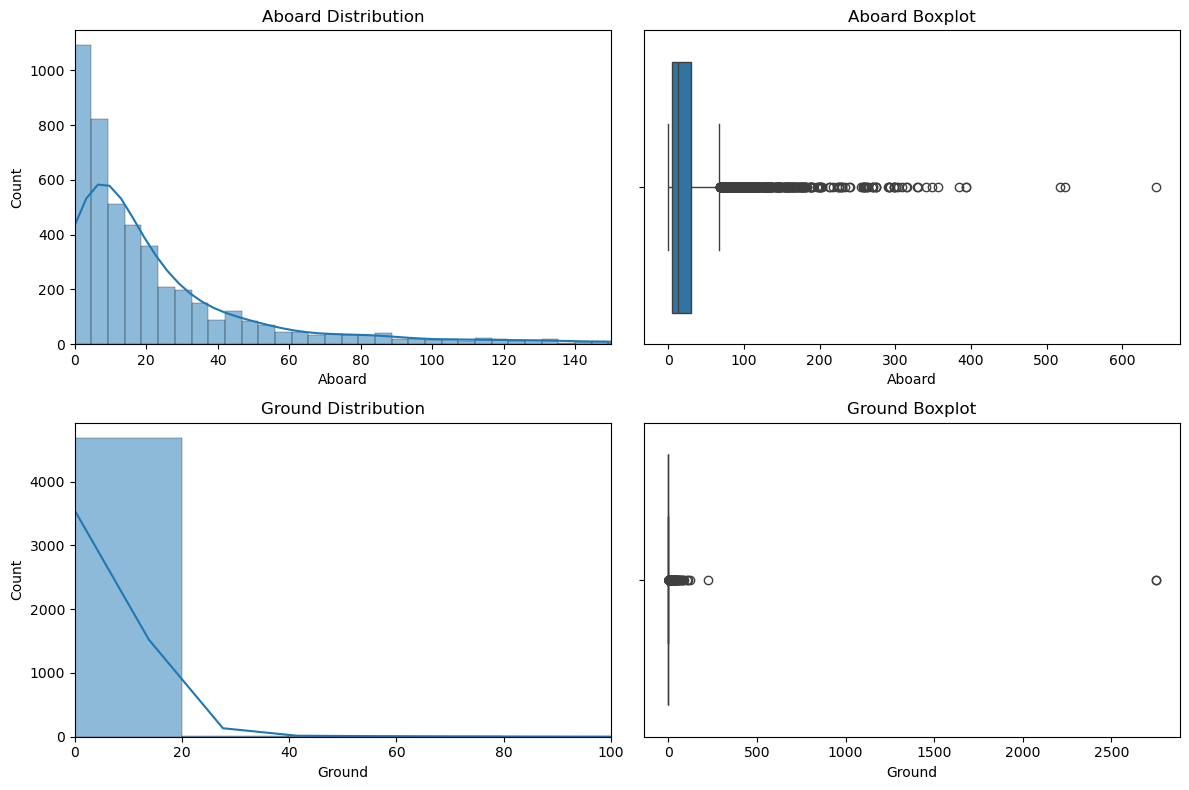

In [179]:
# distribution check of 'Aboard' and 'Ground'
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Aboard histogram
sns.histplot(df["Aboard"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Aboard Distribution")

# Aboard boxplot
sns.boxplot(x=df["Aboard"], ax=axes[0,1])
axes[0,1].set_title("Aboard Boxplot")

# Ground histogram
sns.histplot(df["Ground"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Ground Distribution")

# Ground boxplot
sns.boxplot(x=df["Ground"], ax=axes[1,1])
axes[1,1].set_title("Ground Boxplot")

# x axis limits
axes[0,0].set_xlim(0, 150)   # Aboard histogram
axes[1,0].set_xlim(0, 100)   # Ground histogram

plt.tight_layout()
plt.show()

In [180]:
# implement StandardScaler()
scaler = StandardScaler()

# fit training data
X_train[["Aboard", "Ground"]] = scaler.fit_transform(X_train[["Aboard", "Ground"]])

#transform test data
X_test[["Aboard", "Ground"]] = scaler.transform(X_test[["Aboard", "Ground"]])

In [181]:
X_train.head(4)

,Aboard,Ground,Training_Flight,Test_Flight,Sightseeing_Flight,Summary_attack,Summary_weather,Summary_fire,Summary_technical,Summary_takeoff_landing,...,Manufacturer_shorts,Manufacturer_sikorsky,Manufacturer_stinson,Manufacturer_sud,Manufacturer_swearingen,Manufacturer_tupolev,Manufacturer_unknown,Manufacturer_vickers,Manufacturer_yakovlev,Manufacturer_zeppelin
4454,-0.549355,-0.032734,0,0,0,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2442,1.256810,-0.032734,0,0,0,0,0,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
799,-0.075237,-0.032734,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
612,-0.549355,-0.032734,0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [182]:
# final checks before model
print(X_train.shape)
print(X_test.shape)

print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

(3784, 84)
(946, 84)
0
0


## Report of section 5. Standardise

Extreme right skew for both 'Aboard' and 'Ground'. Therefore, standardisation was used to scale both of these. This deals with outliers better than normalisation

## 6. Building the models

### 6.1. Linear Regression

In [183]:
# build model
linear_model = LinearRegression()

# fit model
linear_model.fit(X_train, y_train)

# predictions
y_pred = linear_model.predict(X_test)

# results
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print("R²:", round(r2, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))

R²: 0.532
MSE: 420.248
RMSE: 20.5
MAE: 9.151


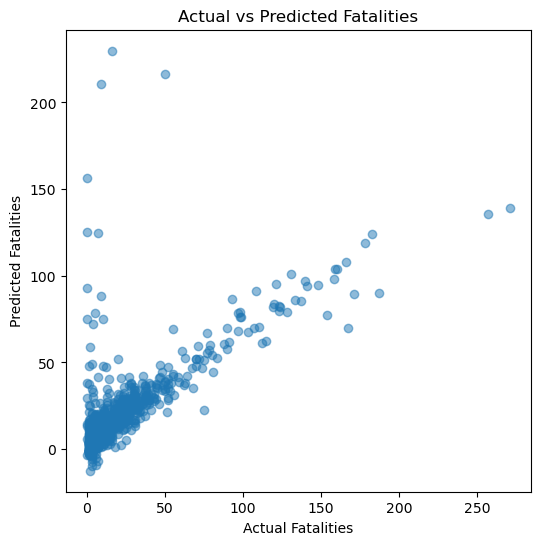

In [184]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Fatalities")
plt.ylabel("Predicted Fatalities")
plt.title("Actual vs Predicted Fatalities")
plt.show()